# 01. Data Exploration & Exploratory Data Analysis (EDA)

**Project:** Customer Churn Prediction – Telecom  
**Goal:** Understand the dataset, discover patterns, and identify key drivers of customer churn.

### Business Questions to Answer
1. What is the overall churn rate?
2. Which customer segments churn the most?
3. How do contract type, tenure, and services relate to churn?
4. Are there strong correlations between numerical features and churn?

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Optional: for nicer plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

Matplotlib is building the font cache; this may take a moment.


## 2. Load the Dataset

Download the **Telco Customer Churn** dataset from Kaggle:  
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Place the file in `../data/raw/telco_customer_churn.csv`

In [2]:
# Load data
df = pd.read_csv('../data/raw/telco_customer_churn.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Basic Data Inspection

In [3]:
# Column names and data types
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Duplicate Rows ===")
print(f"Duplicates: {df.duplicated().sum()}")

=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

Duplicates: 0


In [4]:
# Statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Statistical summary of categorical columns
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [6]:
# Unique values in each column
print("=== Unique Values per Column ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

=== Unique Values per Column ===
customerID: 7043 unique values
gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 73 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1585 unique values
TotalCharges: 6531 unique values
Churn: 2 unique values


### Quick Fix Preview: TotalCharges
TotalCharges is often stored as object (string) because of blank values for new customers (tenure = 0).

In [7]:
# Check TotalCharges issues
print(df['TotalCharges'].dtype)
print("Blank / space values:", (df['TotalCharges'] == ' ').sum())
df[df['TotalCharges'] == ' '][['customerID', 'tenure', 'TotalCharges', 'Churn']].head()

str
Blank / space values: 11


,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No


## 4. Target Variable Analysis – Churn Rate

Churn Counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate (%):
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


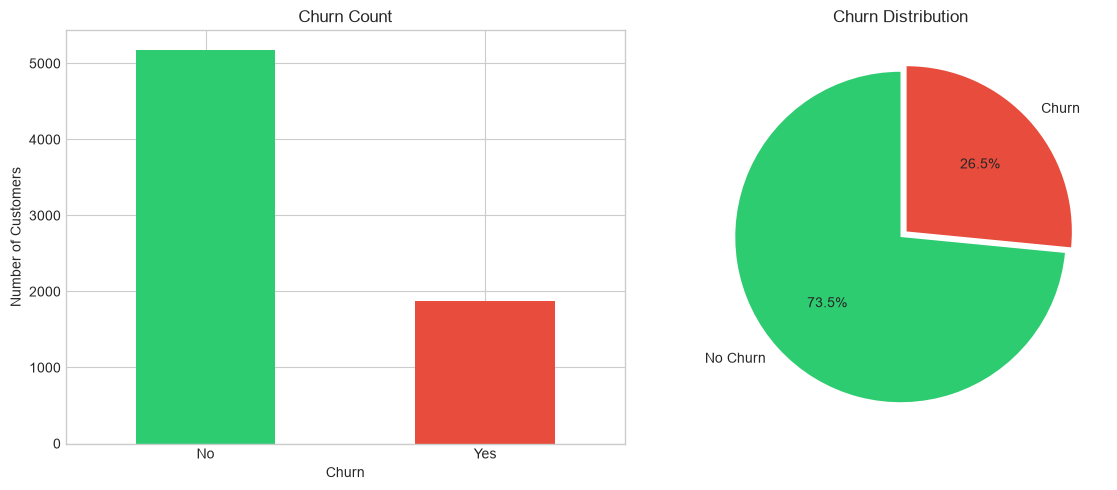

In [8]:
# Overall churn rate
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:\n", churn_counts)
print("\nChurn Rate (%):\n", churn_rate.round(2))

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

churn_counts.plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Churn Count')
ax[0].set_ylabel('Number of Customers')
ax[0].set_xticklabels(['No', 'Yes'], rotation=0)

ax[1].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
          colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.05))
ax[1].set_title('Churn Distribution')

plt.tight_layout()
plt.show()

## 5. Univariate Analysis – Numerical Features

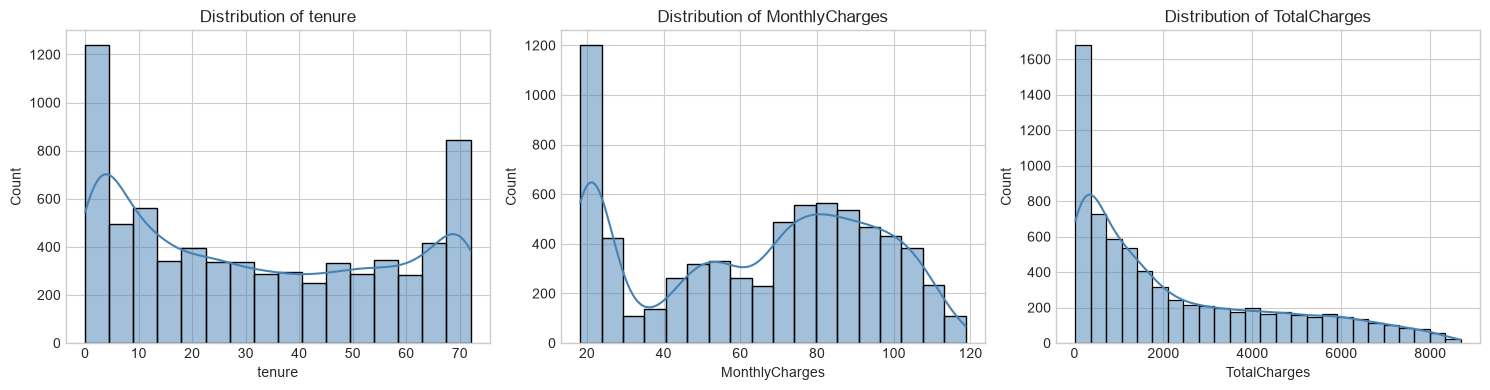

In [9]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']  # TotalCharges will be fixed later

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['tenure', 'MonthlyCharges']):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

# Temporary conversion for visualization
temp = pd.to_numeric(df['TotalCharges'], errors='coerce')
sns.histplot(temp.dropna(), kde=True, ax=axes[2], color='steelblue')
axes[2].set_title('Distribution of TotalCharges')

plt.tight_layout()
plt.show()

## 6. Univariate Analysis – Categorical Features

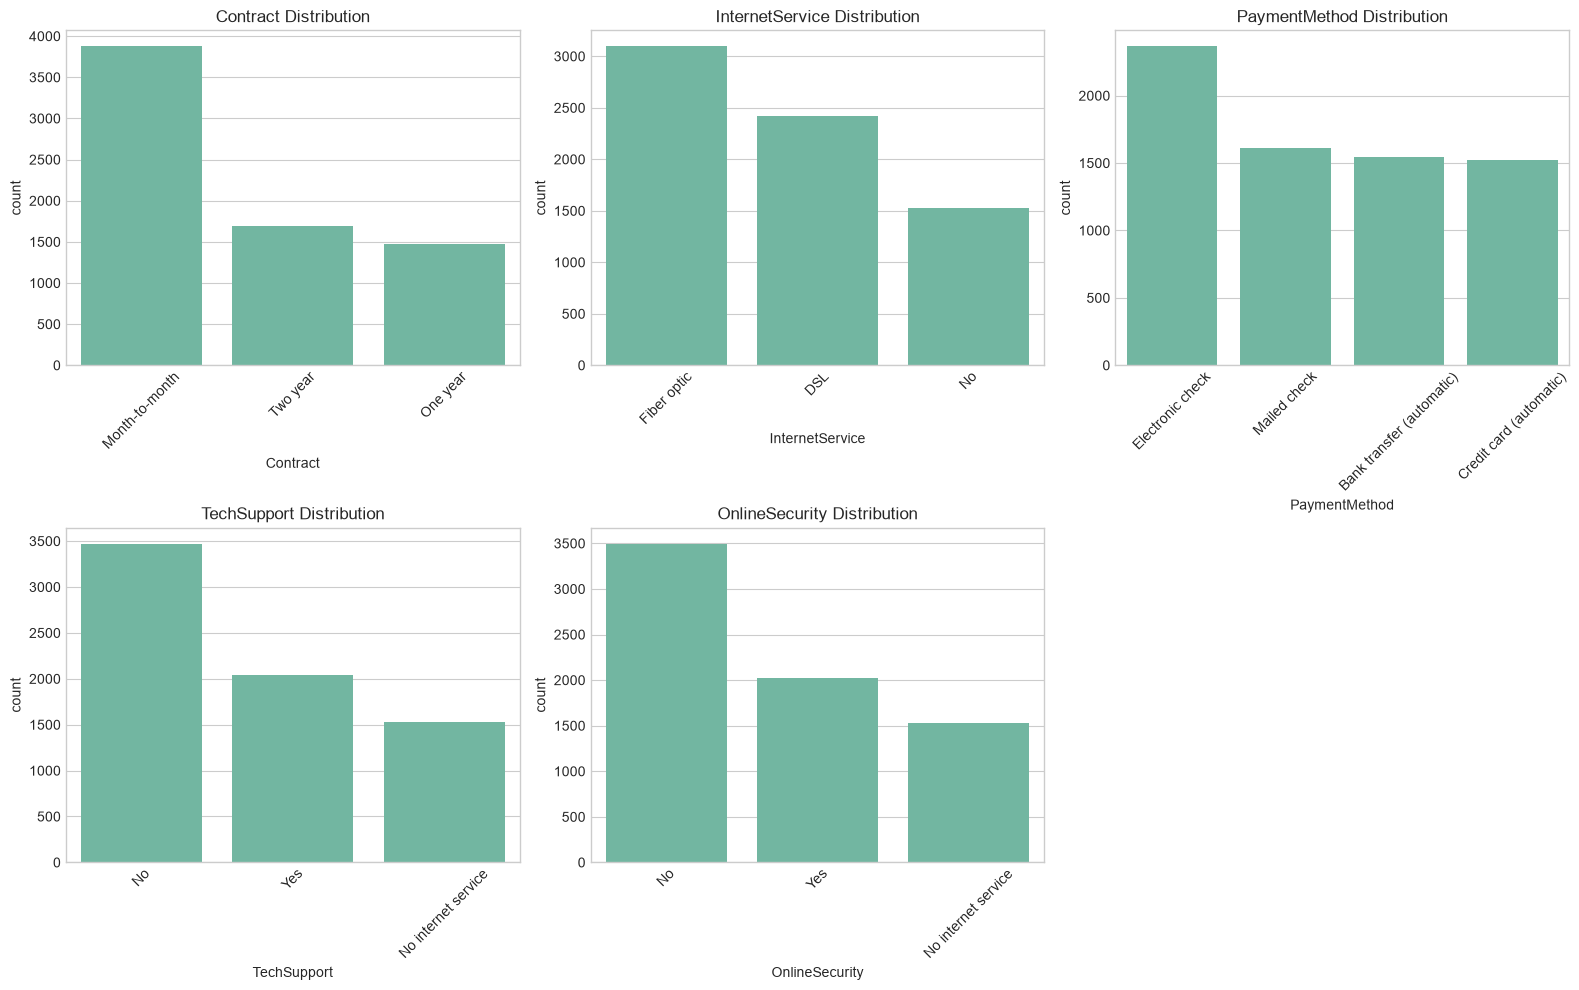

In [10]:
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Plot a few important ones (you can loop over all)
important_cats = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(important_cats):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'{col} Distribution')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Bivariate Analysis – Churn vs Categorical Features

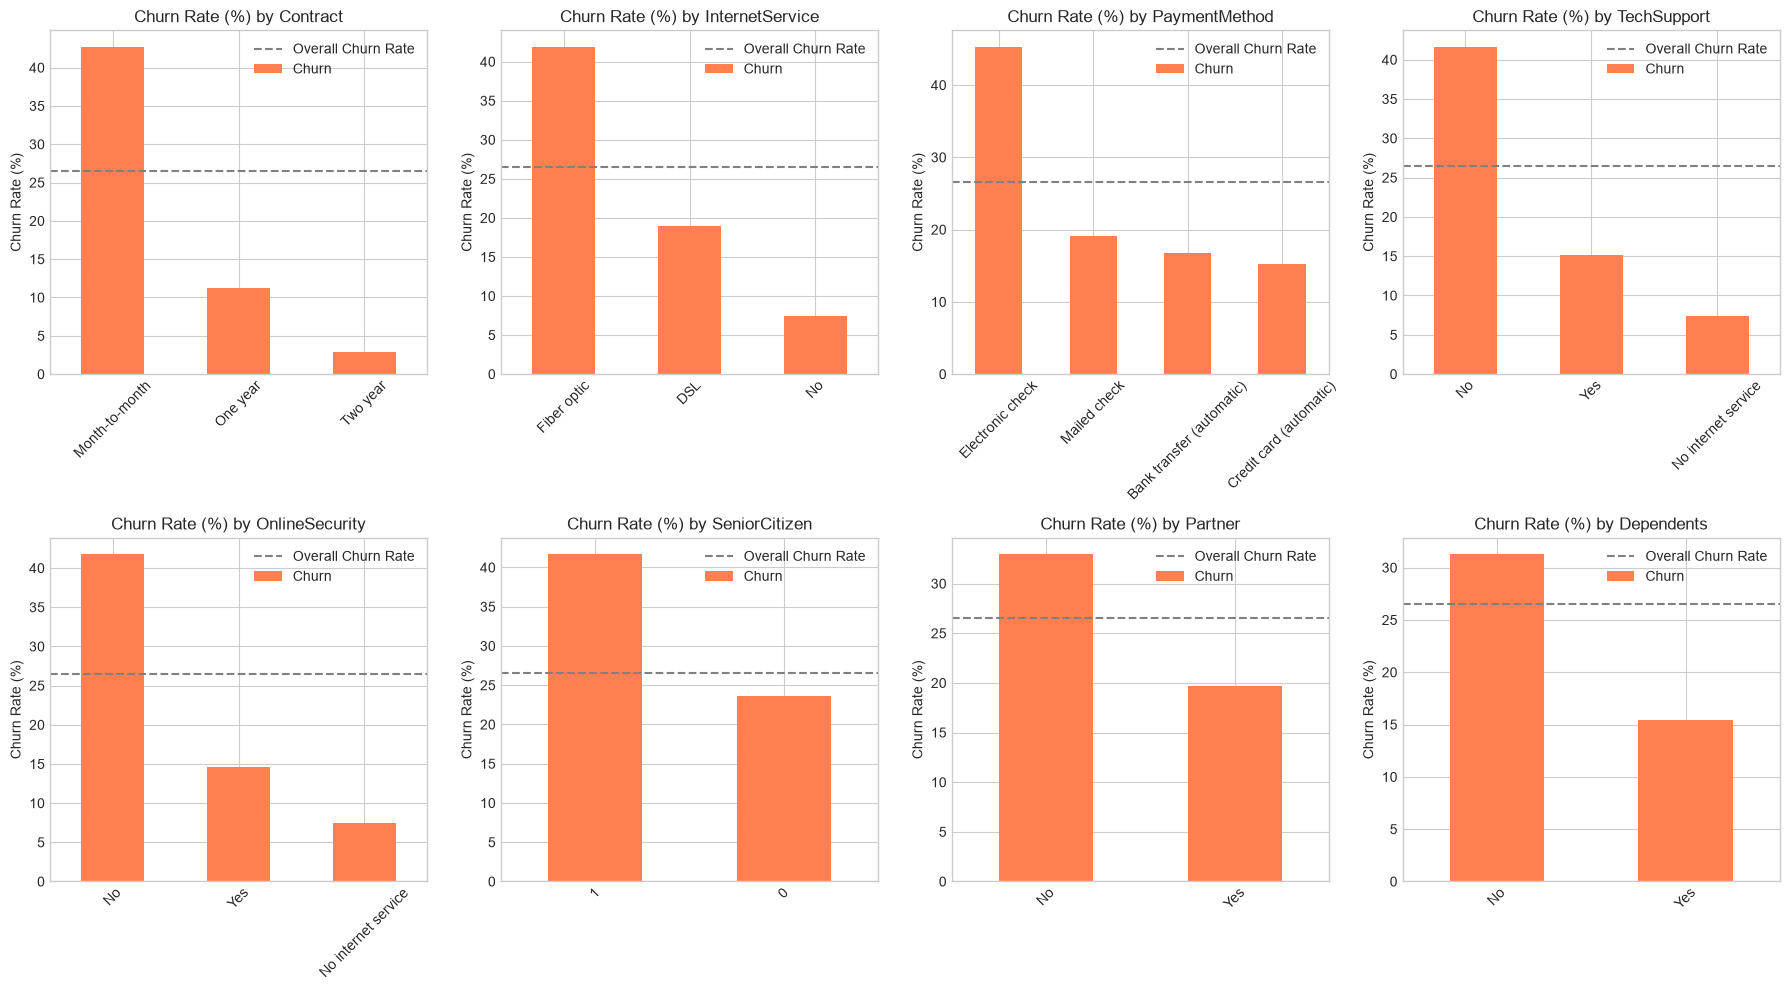

In [11]:
def plot_churn_rate(df, column, ax=None):
    """Plot churn rate (%) by a categorical column"""
    churn_pct = df.groupby(column)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    churn_pct.plot(kind='bar', ax=ax, color='coral')
    ax.set_title(f'Churn Rate (%) by {column}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=df['Churn'].eq('Yes').mean()*100, color='gray', linestyle='--', label='Overall Churn Rate')
    ax.legend()
    return ax

# Key categorical features vs Churn
key_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 
                'OnlineSecurity', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    plot_churn_rate(df, col, ax=axes[i])

plt.tight_layout()
plt.show()

## 8. Bivariate Analysis – Churn vs Numerical Features

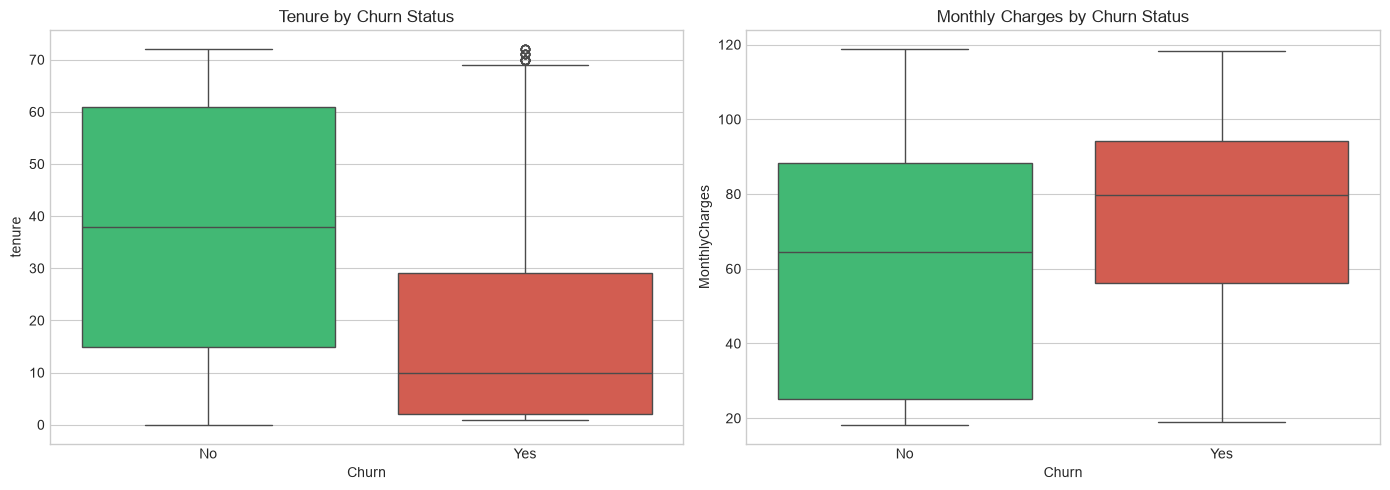

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure vs Churn
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Tenure by Churn Status')

# MonthlyCharges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Monthly Charges by Churn Status')

plt.tight_layout()
plt.show()

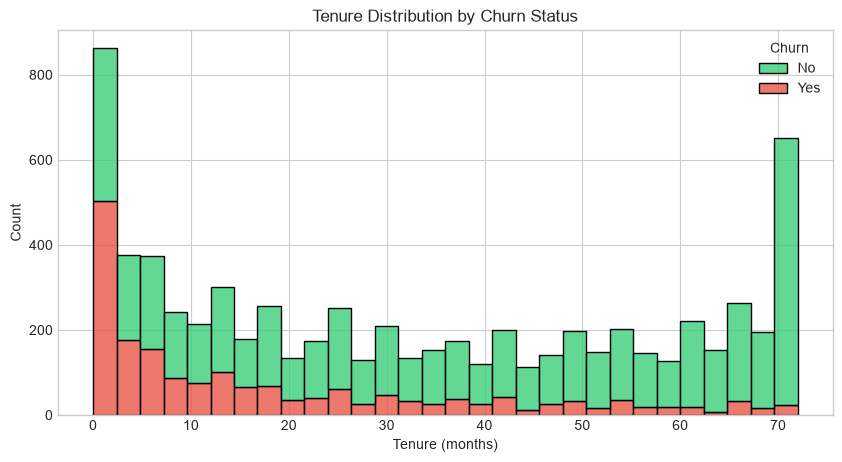

In [13]:
# Tenure distribution by Churn (histogram)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, palette=['#2ecc71', '#e74c3c'])
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.show()

## 9. Correlation Analysis (after temporary conversion)

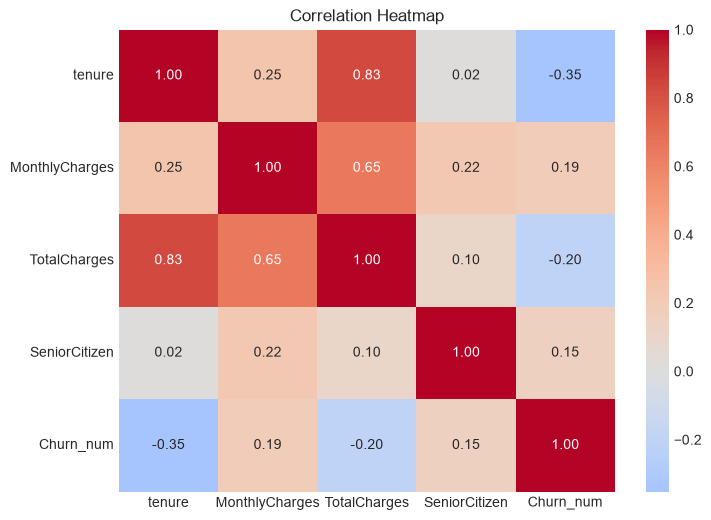

In [14]:
# Temporary conversion for correlation
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')
df_temp['Churn_num'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']
corr_matrix = df_temp[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 10. Key Insights from EDA (Write your findings here)

After running the above cells, fill in the insights:

| Insight | Finding |
|---------|---------|
| Overall Churn Rate | ~26.5% |
| Highest risk contract | Month-to-month |
| Internet Service risk | Fiber optic usually highest |
| Tenure pattern | Short tenure → much higher churn |
| Payment Method | Electronic check often highest risk |
| Support services | No Tech Support / No Online Security → higher churn |
| Monthly Charges | Churners tend to have higher average monthly charges |

### Next Steps
→ Go to **02_data_preprocessing_feature_engineering.ipynb**